# task 1

In [2]:
import numpy as np
np.random.seed(42)
orders = np.random.randint(100, 801, size=30)
revenue = np.random.uniform(5000, 50000, size=30)
total_orders = np.sum(orders)
total_revenue = np.sum(revenue)
mean_orders = np.mean(orders)
std_orders = np.std(orders)
max_rev_day = np.argmax(revenue)
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ${total_revenue:.2f}")
print(f"Mean Orders: {mean_orders:.2f}, Std Dev: {std_orders:.2f}")
print(f"Day with Highest Revenue: Day {max_rev_day}")
surge_mask = orders > (mean_orders + std_orders)
peak_days_count = np.sum(surge_mask)
peak_combined_revenue = np.sum(revenue[surge_mask])
print(f"\nPeak Days Count: {peak_days_count}")
print(f"Peak Days Combined Revenue: ${peak_combined_revenue:.2f}")
weekly_orders = orders.reshape(5, 6)
weekly_totals = np.sum(weekly_orders, axis=1)
print(f"\nTotal Orders per Weekly Block: {weekly_totals}")

Total Orders: 12279
Total Revenue: $743362.93
Mean Orders: 409.30, Std Dev: 195.90
Day with Highest Revenue: Day 10

Peak Days Count: 4
Peak Days Combined Revenue: $127639.11

Total Orders per Weekly Block: [2284 2365 2409 3201 2020]


# task 2

In [3]:
import pandas as pd
import numpy as np
data = {
    'order_id': list(range(1, 21)),
    'customer_name': ['Customer_' + str(i) for i in range(1, 21)],
    'restaurant_name': ['Rest A', 'Rest B', 'Rest C', 'Rest D'] * 5,
    'category': ['Italian', 'Fast Food', np.nan, 'Healthy'] * 5,
    'delivery_time_mins': [25, np.nan, 45, 15, 60] * 4,
    'order_value': [15.0, 22.5, 110.0, np.nan, 12.0] * 4,
    'rating': [4.5, 3.0, np.nan, 5.0, 4.0] * 4
}
df = pd.DataFrame(data)
df = pd.concat([df, df.iloc[:3]])
print("Null counts BEFORE filling:\n", df.isnull().sum())
df['delivery_time_mins'] = df['delivery_time_mins'].fillna(df['delivery_time_mins'].median())
df['order_value'] = df['order_value'].fillna(df['order_value'].median())
df['rating'] = df['rating'].fillna(round(df['rating'].mean(), 1))
df['category'] = df['category'].fillna(df['category'].mode()[0])
print("\nNull counts AFTER filling:\n", df.isnull().sum())
print(f"\nShape before deduplication: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after deduplication: {df.shape}")
Q1 = df['order_value'].quantile(0.25)
Q3 = df['order_value'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
outliers = df[df['order_value'] > upper_fence]
print("\nOutlier Rows:\n", outliers[['order_id', 'order_value']])
df['order_value'] = df['order_value'].clip(upper=upper_fence)

Null counts BEFORE filling:
 order_id              0
customer_name         0
restaurant_name       0
category              6
delivery_time_mins    5
order_value           4
rating                5
dtype: int64

Null counts AFTER filling:
 order_id              0
customer_name         0
restaurant_name       0
category              0
delivery_time_mins    0
order_value           0
rating                0
dtype: int64

Shape before deduplication: (23, 7)
Shape after deduplication: (20, 7)

Outlier Rows:
     order_id  order_value
2          3        110.0
7          8        110.0
12        13        110.0
17        18        110.0


# task 4

Figure successfully saved as food_delivery_dashboard.png


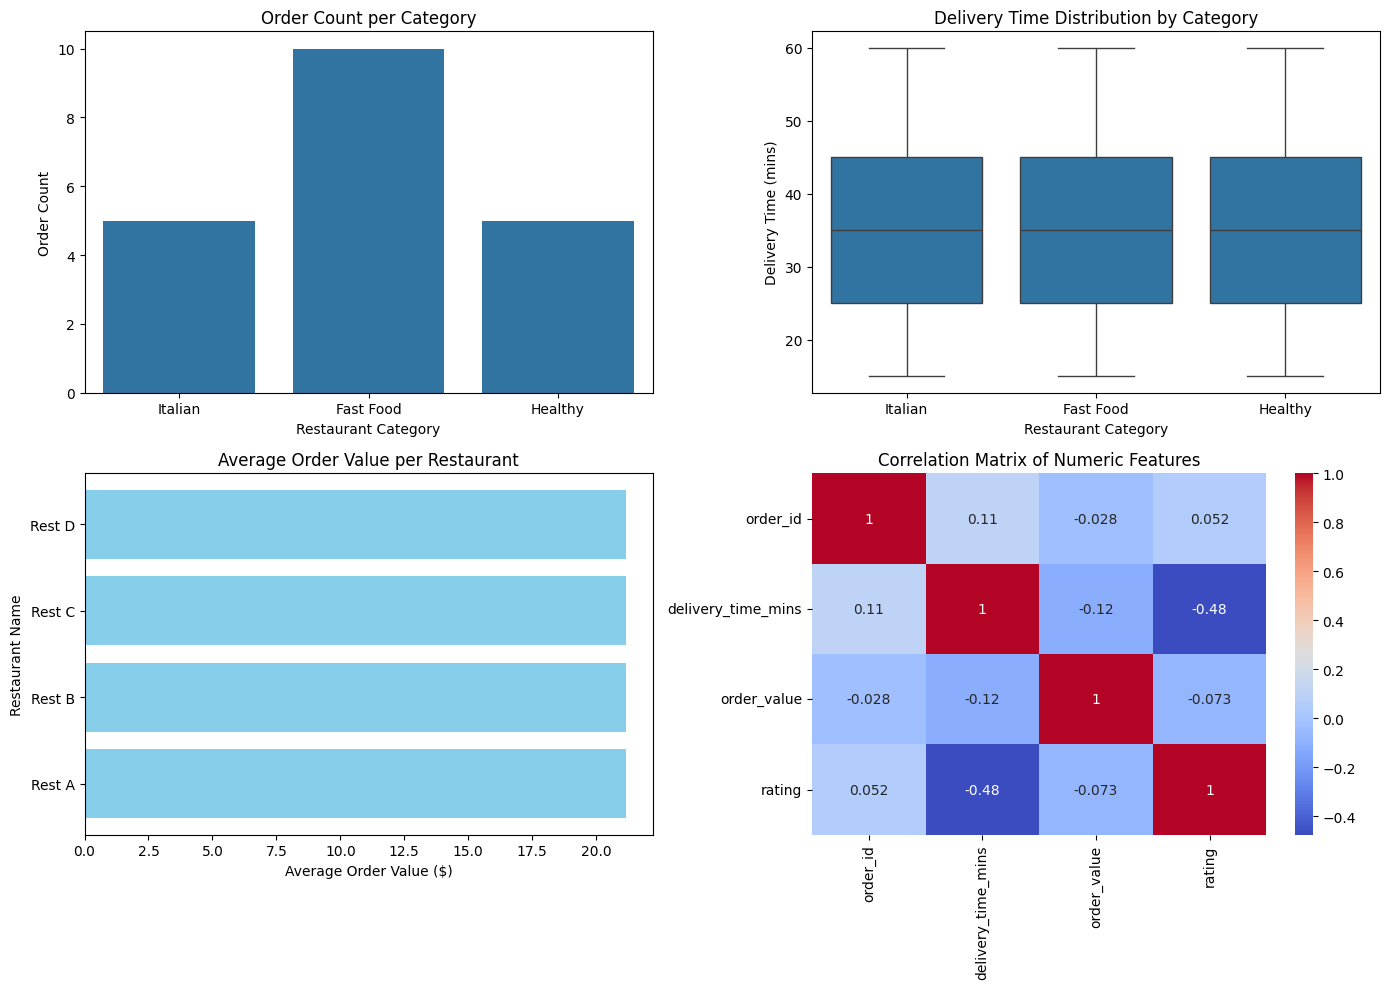

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x='category', ax=axes[0, 0])
axes[0, 0].set_title('Order Count per Category')
axes[0, 0].set_xlabel('Restaurant Category')
axes[0, 0].set_ylabel('Order Count')
sns.boxplot(data=df, x='category', y='delivery_time_mins', ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time Distribution by Category')
axes[0, 1].set_xlabel('Restaurant Category')
axes[0, 1].set_ylabel('Delivery Time (mins)')
avg_order = df.groupby('restaurant_name')['order_value'].mean().reset_index()
axes[1, 0].barh(avg_order['restaurant_name'], avg_order['order_value'], color='skyblue')
axes[1, 0].set_title('Average Order Value per Restaurant')
axes[1, 0].set_xlabel('Average Order Value ($)')
axes[1, 0].set_ylabel('Restaurant Name')
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('food_delivery_dashboard.png', dpi=150, bbox_inches='tight')
print("Figure successfully saved as food_delivery_dashboard.png")

# task 5

In [5]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('food_delivery.db')
cursor = conn.cursor()
cursor.execute('''CREATE TABLE IF NOT EXISTS restaurants 
                  (restaurant_id INTEGER PRIMARY KEY, name TEXT, category TEXT, city TEXT)''')
cursor.execute('''CREATE TABLE IF NOT EXISTS orders 
                  (order_id INTEGER PRIMARY KEY, restaurant_id INTEGER, order_value REAL, 
                  delivery_time_mins REAL, rating REAL)''')
cursor.executemany('INSERT OR IGNORE INTO restaurants VALUES (?, ?, ?, ?)', [
    (1, 'Pasta Palace', 'Italian', 'NYC'), (2, 'Burger Boss', 'Fast Food', 'NYC'),
    (3, 'Sushi Station', 'Japanese', 'LA'), (4, 'Green Bowl', 'Healthy', 'LA'),
    (5, 'Taco Town', 'Mexican', 'CHI'), (6, 'Curry House', 'Indian', 'CHI'),
    (7, 'Pizza Paradise', 'Italian', 'MIA'), (8, 'Wok Way', 'Chinese', 'MIA')
])
orders_data = [(i, (i%8)+1, 15.0 + i, 20 + (i%10), 4.0 + (i%10)*0.1) for i in range(1, 26)]
cursor.executemany('INSERT OR IGNORE INTO orders VALUES (?, ?, ?, ?, ?)', orders_data)
conn.commit()
query = '''
SELECT r.name, 
       COUNT(o.order_id) AS total_orders, 
       SUM(o.order_value) AS total_revenue, 
       ROUND(AVG(o.rating), 2) AS avg_rating
FROM restaurants r
LEFT JOIN orders o ON r.restaurant_id = o.restaurant_id
GROUP BY r.name
'''
df_sql = pd.read_sql_query(query, conn)
df_sql['revenue_rank'] = df_sql['total_revenue'].rank(ascending=False, method='min').astype(int)
df_sql = df_sql.sort_values('revenue_rank')
print("Full Restaurant Table Sorted By Rank:")
print(df_sql.to_string(index=False))
print("\nTop 5 Restaurants by Total Revenue:")
print(df_sql.head(5).to_string(index=False))
df_sql.to_csv('restaurant_performance_report.csv', index=False)
conn.close()

Full Restaurant Table Sorted By Rank:
          name  total_orders  total_revenue  avg_rating  revenue_rank
   Burger Boss             4          112.0        4.55             1
  Pasta Palace             3           93.0        4.60             2
       Wok Way             3           90.0        4.50             3
Pizza Paradise             3           87.0        4.40             4
   Curry House             3           84.0        4.30             5
     Taco Town             3           81.0        4.20             6
    Green Bowl             3           78.0        4.43             7
 Sushi Station             3           75.0        4.33             8

Top 5 Restaurants by Total Revenue:
          name  total_orders  total_revenue  avg_rating  revenue_rank
   Burger Boss             4          112.0        4.55             1
  Pasta Palace             3           93.0        4.60             2
       Wok Way             3           90.0        4.50             3
Pizza Paradise 